In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

In [5]:
#Load the data
df = pd.read_csv("train.csv")
print(f"Shape: {df.shape}")
df.head(2)

Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94


In [6]:
#Data cleaning
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
Postal Code    11
dtype: int64

Duplicate rows: 0


In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.strftime("%b")
df["Quarter"] = df["Order Date"].dt.quarter
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df.drop_duplicates(inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Quarter,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,Nov,4,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,Nov,4,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,Jun,2,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,Oct,4,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,Oct,4,7


In [8]:
#SQL analysis

In [10]:
conn = sqlite3.connect(":memory:")
df.to_sql("sales",conn,index=False,if_exists="replace")

9800

In [11]:
# Monthly revenue trend
query = """
SELECT Year, Month, Month_Name AS "Month Name", ROUND(SUM(Sales), 2) AS Revenue
FROM sales
GROUP BY Year, Month
ORDER BY Year, Month;
"""
# SQLite column names with spaces need quoting; rename via pandas beforehand
df_sql = df.rename(columns={"Month Name": "Month_Name"})
df_sql.to_sql("sales", conn, index=False, if_exists="replace")
monthly_revenue = pd.read_sql(query, conn)
monthly_revenue.tail(12)

,Year,Month,Month Name,Revenue
36,2018,1,Jan,43476.47
37,2018,2,Feb,19921.00
38,2018,3,Mar,58863.41
39,2018,4,Apr,35541.91
40,2018,5,May,43825.98
41,2018,6,Jun,48190.73
42,2018,7,Jul,44825.10
43,2018,8,Aug,62837.85
44,2018,9,Sep,86152.89
45,2018,10,Oct,77448.13


In [12]:
# Top 10 products by revenue
query = """
SELECT "Product Name", Category, ROUND(SUM(Sales), 2) AS Revenue, COUNT(*) AS Orders
FROM sales
GROUP BY "Product Name"
ORDER BY Revenue DESC
LIMIT 10;
"""
top_products = pd.read_sql(query, conn)
top_products

,Product Name,Category,Revenue,Orders
0,Canon imageCLASS 2200 Advanced Copier,Technology,61599.82,5
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,27453.38,10
2,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.48,1
3,HON 5400 Series Task Chairs for Big and Tall,Furniture,21870.58,8
4,GBC DocuBind TL300 Electric Binding System,Office Supplies,19823.48,11
5,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,19024.50,9
6,Hewlett Packard LaserJet 3310 Copier,Technology,18839.69,8
7,HP Designjet T520 Inkjet Large Format Printer ...,Technology,18374.90,3
8,GBC DocuBind P400 Electric Binding System,Office Supplies,17965.07,6
9,High Speed Automatic Electric Letter Opener,Office Supplies,17030.31,3


In [13]:
# Revenue and order count by customer segment and region
query = """
SELECT Segment, Region, ROUND(SUM(Sales), 2) AS Revenue, COUNT(DISTINCT "Order ID") AS Orders
FROM sales
GROUP BY Segment, Region
ORDER BY Revenue DESC;
"""
segment_region = pd.read_sql(query, conn)
segment_region

,Segment,Region,Revenue,Orders
0,Consumer,West,355241.19,811
1,Consumer,East,347906.61,698
2,Consumer,Central,250210.52,590
3,Corporate,West,220018.28,478
4,Corporate,East,195897.42,424
5,Consumer,South,194702.21,438
6,Corporate,Central,152031.50,345
7,Home Office,West,134960.21,298
8,Home Office,East,125714.70,247
9,Corporate,South,120546.87,244


In [14]:
# Top customers by lifetime revenue
query = """
SELECT "Customer Name", Segment, ROUND(SUM(Sales), 2) AS "Lifetime Revenue", COUNT(DISTINCT "Order ID") AS Orders
FROM sales
GROUP BY "Customer Name"
ORDER BY "Lifetime Revenue" DESC
LIMIT 10;
"""
top_customers = pd.read_sql(query, conn)
top_customers

,Customer Name,Segment,Lifetime Revenue,Orders
0,Sean Miller,Home Office,25043.05,5
1,Tamara Chand,Corporate,19052.22,5
2,Raymond Buch,Consumer,15117.34,6
3,Tom Ashbrook,Home Office,14595.62,4
4,Adrian Barton,Consumer,14473.57,10
5,Ken Lonsdale,Consumer,14175.23,12
6,Sanjit Chand,Consumer,14142.33,9
7,Hunter Lopez,Consumer,12873.30,6
8,Sanjit Engle,Consumer,12209.44,11
9,Christopher Conant,Consumer,12129.07,5


In [15]:
#EDA

In [16]:
#Purchasing trends
order_freq = df.groupby("Customer ID")["Order ID"].nunique().sort_values(ascending=False)
print(f"Total unique customers: {df['Customer ID'].nunique()}")
print(f"Average orders per customer: {order_freq.mean():.2f}")
print(f"Customers with 5+ orders: {(order_freq >= 5).sum()} ({(order_freq >= 5).mean()*100:.1f}%)")
order_freq.describe()

Total unique customers: 793
Average orders per customer: 6.21
Customers with 5+ orders: 585 (73.8%)


count    793.000000
mean       6.206810
std        2.525647
min        1.000000
25%        4.000000
50%        6.000000
75%        8.000000
max       17.000000
Name: Order ID, dtype: float64

In [17]:
#seasonal sales patterns
seasonal = df.groupby(["Year", "Month"])["Sales"].sum().reset_index()
seasonal_pivot = df.groupby(["Month"])["Sales"].mean()
month_avg = df.pivot_table(index="Month", columns="Year", values="Sales", aggfunc="sum")
month_avg

Year,2015,2016,2017,2018
Month,,,,
1,14205.7070,18066.9576,18542.4910,43476.4740
2,4519.8920,11951.4110,22978.8150,19920.9974
3,55205.7970,32339.3184,51165.0590,58863.4128
4,27906.8550,34154.4685,38679.7670,35541.9101
5,23644.3030,29959.5305,56656.9080,43825.9822
6,34322.9356,23599.3740,39724.4860,48190.7277
7,33781.5430,28608.2590,38320.7830,44825.1040
8,27117.5365,36818.3422,30542.2003,62837.8480
9,81623.5268,63133.6060,69193.3909,86152.8880


In [19]:
#top performing categories
category_perf = df.groupby(["Category", "Sub-Category"]).agg(
    Revenue=("Sales", "sum"),
    Orders=("Order ID", "nunique"),
    Avg_Order_Value=("Sales", "mean")
).sort_values("Revenue", ascending=False).round(2)
category_perf

Revenue  Orders  Avg_Order_Value
Category        Sub-Category                                    
Technology      Phones        327782.45     803           374.18
Furniture       Chairs        322822.73     566           531.83
Office Supplies Storage       219343.39     764           263.63
Furniture       Tables        202810.63     302           645.89
Office Supplies Binders       200028.78    1291           134.07
Technology      Machines      189238.63     112          1645.55
                Accessories   164186.70     702           217.18
                Copiers       146248.09      66          2215.88
Furniture       Bookcases     113813.20     222           503.60
Office Supplies Appliances    104618.40     444           227.93
Furniture       Furnishings    89212.02     855            95.82
Office Supplies Paper          76828.30    1163            57.42
                Supplies       46420.31     181           252.28
                Art            26705.41     720            34.02
                Envelopes      16128.05     243            65.03
                Labels         12347.73     340            34.59
                Fasteners       3001.96     212            14.03

In [20]:
#visualization

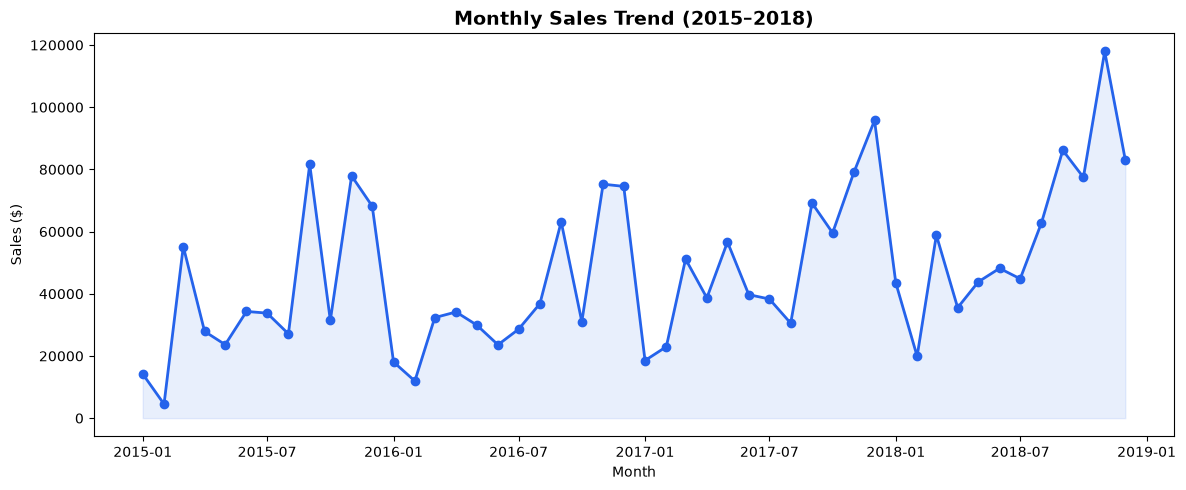

In [21]:
#monthly sales trend
fig, ax = plt.subplots(figsize=(12, 5))
monthly = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
monthly.index = monthly.index.to_timestamp()
ax.plot(monthly.index, monthly.values, marker="o", linewidth=2, color="#2563eb")
ax.set_title("Monthly Sales Trend (2015–2018)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Sales ($)")
ax.fill_between(monthly.index, monthly.values, alpha=0.1, color="#2563eb")
plt.tight_layout()
plt.savefig("chart_monthly_trend.png", dpi=150)
plt.show()

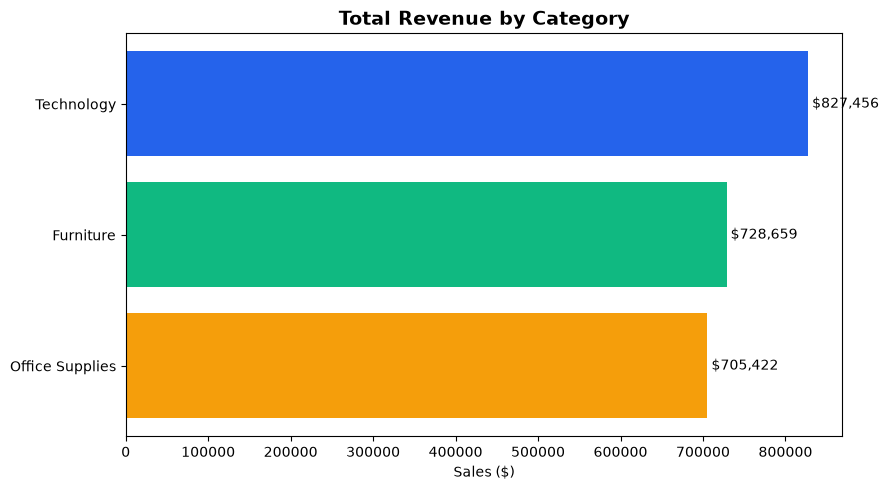

In [22]:
#revenue by category
fig, ax = plt.subplots(figsize=(9, 5))
cat_revenue = df.groupby("Category")["Sales"].sum().sort_values(ascending=True)
bars = ax.barh(cat_revenue.index, cat_revenue.values, color=["#f59e0b", "#10b981", "#2563eb"])
ax.set_title("Total Revenue by Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Sales ($)")
for bar in bars:
    w = bar.get_width()
    ax.text(w, bar.get_y() + bar.get_height()/2, f" ${w:,.0f}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("chart_category_revenue.png", dpi=150)
plt.show()

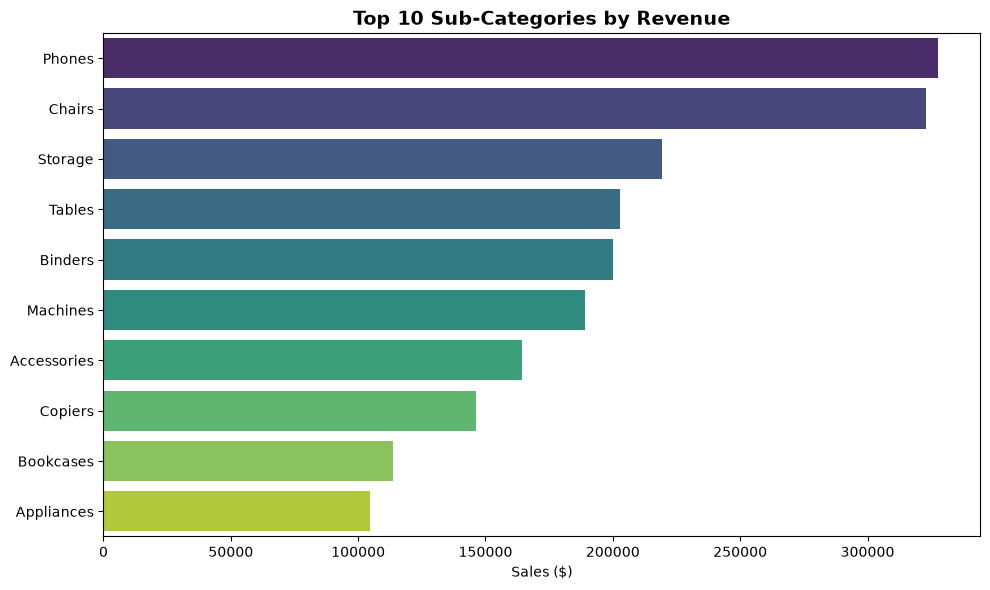

In [23]:
#top 10 sub-catgroies by revenue
fig, ax = plt.subplots(figsize=(10, 6))
subcat = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=subcat.values, y=subcat.index, hue=subcat.index, palette="viridis", legend=False, ax=ax)
ax.set_title("Top 10 Sub-Categories by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Sales ($)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("chart_top_subcategories.png", dpi=150)
plt.show()

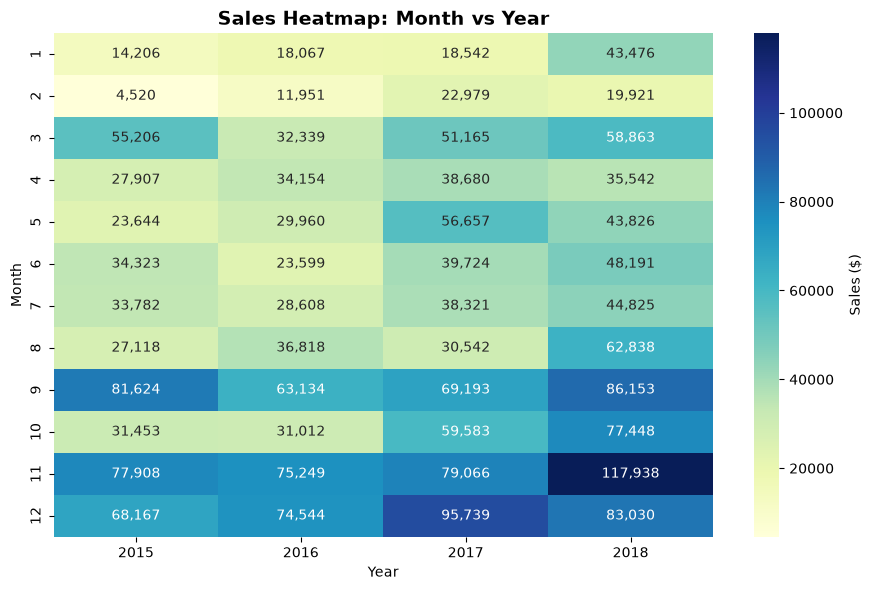

In [24]:
#seasonal heatmap(sales by month vs year)
fig, ax = plt.subplots(figsize=(9, 6))
heat_data = df.pivot_table(index="Month", columns="Year", values="Sales", aggfunc="sum")
sns.heatmap(heat_data, annot=True, fmt=",.0f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "Sales ($)"})
ax.set_title("Sales Heatmap: Month vs Year", fontsize=14, fontweight="bold")
ax.set_ylabel("Month")
plt.tight_layout()
plt.savefig("chart_seasonality_heatmap.png", dpi=150)
plt.show()

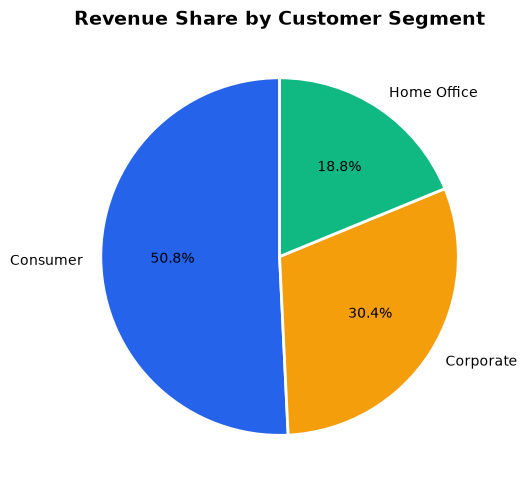

In [25]:
#sales distribution by customer segment
fig, ax = plt.subplots(figsize=(8, 5))
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
colors = ["#2563eb", "#f59e0b", "#10b981"]
ax.pie(segment_sales.values, labels=segment_sales.index, autopct="%1.1f%%",
       colors=colors, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Revenue Share by Customer Segment", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_segment_share.png", dpi=150)
plt.show()

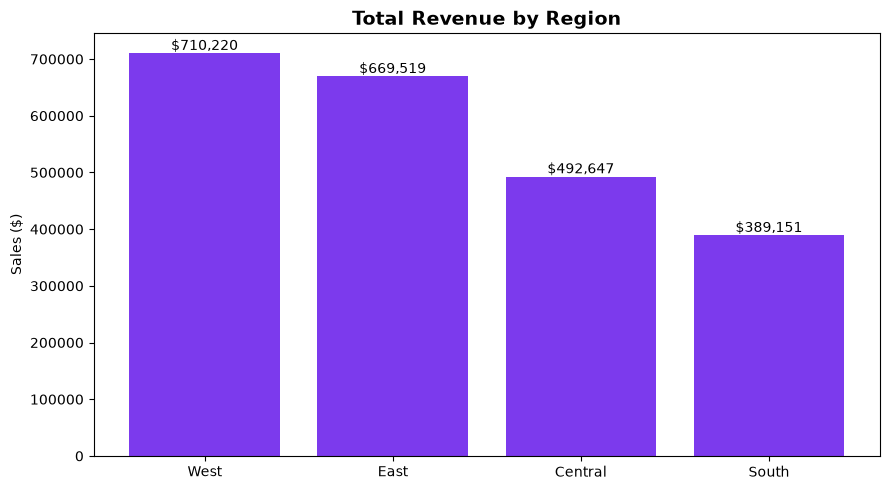

In [27]:
#regional performance
fig, ax = plt.subplots(figsize=(9, 5))
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
bars = ax.bar(region_sales.index, region_sales.values, color="#7c3aed")
ax.set_title("Total Revenue by Region", fontsize=14, fontweight="bold")
ax.set_ylabel("Sales ($)")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f"${h:,.0f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("chart_region_revenue.png", dpi=150)
plt.show()

## 6. Key Insights

- **Seasonality is real:** sales consistently spike in **November–December** each year, with a smaller peak in September — pointing to holiday and back-to-office buying cycles.
- **Category concentration:** *Technology* and *Furniture* generate the highest revenue per order, while *Office Supplies* drives the highest order volume but lower average order value.
- **Sub-category leaders:** a small number of sub-categories (e.g. Phones, Chairs, Storage) account for a disproportionate share of total revenue — classic 80/20 pattern.
- **Customer segment mix:** the *Consumer* segment contributes the largest share of revenue, but *Corporate* and *Home Office* customers show fewer, higher-value orders.
- **Regional skew:** the *West* and *East* regions outperform *Central* and *South*, suggesting where marketing/logistics investment could be prioritized.

## 7. Next Steps
- Layer in `Profit` and `Discount` fields (if available in the full dataset) to analyze profitability, not just revenue.
- Build a customer RFM (Recency, Frequency, Monetary) segmentation for targeted retention campaigns.
- Forecast next-quarter sales using the monthly trend (e.g. with a simple moving average or Prophet).
